In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("Dataset for project.csv")

# Display basic information
print(df.info())
print(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order_ID          10000 non-null  object 
 1   Customer_Name     10000 non-null  object 
 2   Age               9755 non-null   float64
 3   Gender            9520 non-null   object 
 4   State             9685 non-null   object 
 5   City              10000 non-null  object 
 6   Product_Category  9460 non-null   object 
 7   Product_Name      10000 non-null  object 
 8   Quantity          10000 non-null  float64
 9   Unit_Price        10000 non-null  float64
 10  Sales_Amount      9625 non-null   float64
 11  Order_Date        10000 non-null  object 
 12  Payment_Method    10000 non-null  object 
 13  Customer_Rating   10000 non-null  float64
 14  Delivery_Status   10000 non-null  object 
dtypes: float64(5), object(10)
memory usage: 1.1+ MB
None
   Order_ID     Customer_Name   Age

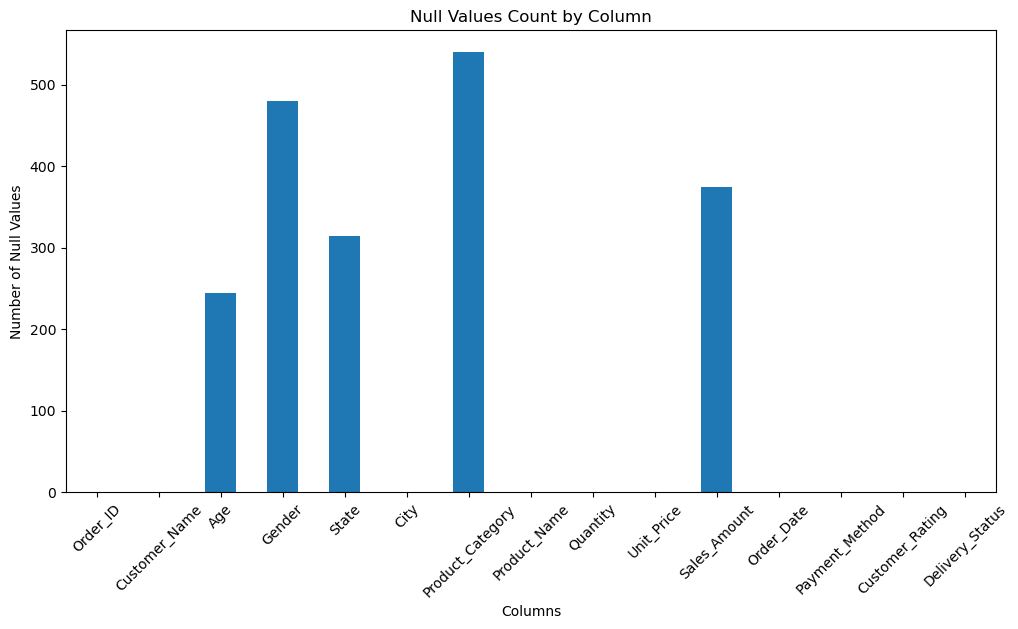

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("Dataset for project.csv")

null_count = df.isnull().sum()

plt.figure(figsize=(12,6))
null_count.plot(kind='bar')
plt.title("Null Values Count by Column")
plt.xlabel("Columns")
plt.ylabel("Number of Null Values")
plt.xticks(rotation=45)
plt.show()

In [3]:
import pandas as pd
import numpy as np

df = pd.read_csv("Dataset for project.csv")

def iqr_batch_normalization(column):
    
    Q1 = np.percentile(column, 25)
    Q2 = np.percentile(column, 50)  
    Q3 = np.percentile(column, 75)
    
    IQR = Q3 - Q1
    

    normalized_column = (column - Q2) / (IQR + 1e-5)
    return normalized_column  


df['Age_Normalized'] = iqr_batch_normalization(df['Age'])
df['Sales_Amount_Normalized'] = iqr_batch_normalization(df['Sales_Amount'])


print("--- After IQR Batch Normalization ---")
print(df[['Age', 'Age_Normalized', 'Sales_Amount', 'Sales_Amount_Normalized']].head())

df.to_csv("batch_normalized_sales_dataset.csv", index=False)

--- After IQR Batch Normalization ---
    Age  Age_Normalized  Sales_Amount  Sales_Amount_Normalized
0  47.0             NaN      29861.58                      NaN
1  52.0             NaN      29861.58                      NaN
2  65.0             NaN      26312.85                      NaN
3  52.0             NaN      11512.28                      NaN
4  58.0             NaN       3969.00                      NaN


In [2]:
import pandas as pd

df = pd.read_csv("sales_dataset_5_columns_missing.csv")

df['Gender'] = df['Gender'].fillna(df['Gender'].mode()[0])
df['State'] = df['State'].fillna(df['State'].mode()[0])
df['Product_Category'] = df['Product_Category'].fillna("unknown")
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Sales_Amount'] = df['Sales_Amount'].fillna(df['Sales_Amount'].median())
print("--- Missing values after cleaning ---")
print(df.isna().sum())
df.to_csv("after cleaned dataset.csv ", index=False)
print("\nSuccess! Dataset is clean and saved as 'after cleaned dataset.csv'")

--- Missing values after cleaning ---
Order_ID            0
Customer_Name       0
Age                 0
Gender              0
State               0
City                0
Product_Category    0
Product_Name        0
Quantity            0
Unit_Price          0
Sales_Amount        0
Order_Date          0
Payment_Method      0
Customer_Rating     0
Delivery_Status     0
dtype: int64

Success! Dataset is clean and saved as 'after cleaned dataset.csv'
